__Ship Fuel Consumption & CO2 Emissions Analysis__

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ship_fuel_efficiency_cleaned.csv')
df


,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61
3,NG001,Oil Service Boat,Port Harcourt-Lagos,April,71.68,Diesel,2393.51,6506.52,Stormy,87.42
4,NG001,Oil Service Boat,Lagos-Apapa,May,134.32,HFO,4267.19,11617.03,Calm,85.61
...,...,...,...,...,...,...,...,...,...,...
1435,NG120,Fishing Trawler,Port Harcourt-Lagos,August,63.84,Diesel,1633.85,4852.28,Stormy,75.88
1436,NG120,Fishing Trawler,Lagos-Apapa,September,61.43,HFO,1263.48,3571.13,Calm,78.00
1437,NG120,Fishing Trawler,Port Harcourt-Lagos,October,193.09,HFO,4661.63,12267.13,Stormy,79.67
1438,NG120,Fishing Trawler,Lagos-Apapa,November,166.50,Diesel,4298.00,12297.71,Moderate,92.87


In [4]:
#Calculate fuel consumption per mile

df['fuel_per_mile'] = df['fuel_consumption'] / df['distance']

In [5]:
#Efficiency Analysis per Ship Type

ship_efficiency = df.groupby('ship_type')['fuel_per_mile'].mean().sort_values(ascending=False)
ship_efficiency

ship_type
Tanker Ship         40.359565
Oil Service Boat    30.235146
Fishing Trawler     25.226427
Surfer Boat         15.055943
Name: fuel_per_mile, dtype: float64

__Visualizing Efficiency__

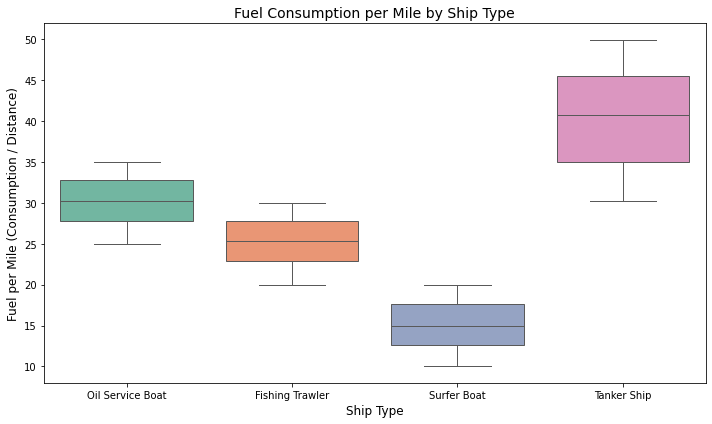

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ship_type', y='fuel_per_mile', hue='ship_type', palette='Set2', legend=False)

plt.title('Fuel Consumption per Mile by Ship Type', fontsize=14)
plt.xlabel('Ship Type', fontsize=12)
plt.ylabel('Fuel per Mile (Consumption / Distance)', fontsize=12)
plt.tight_layout()
plt.show()

__Relationship Between Fuel Consumption and CO2 Emissions__

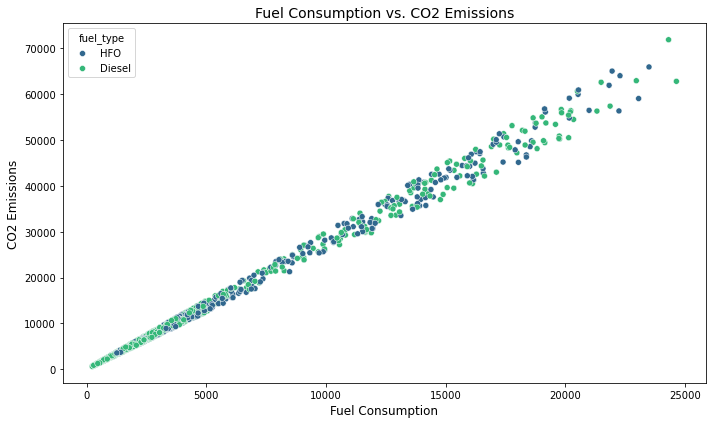

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='fuel_consumption', y='CO2_emissions', hue='fuel_type', palette='viridis')

plt.title('Fuel Consumption vs. CO2 Emissions', fontsize=14)
plt.xlabel('Fuel Consumption', fontsize=12)
plt.ylabel('CO2 Emissions', fontsize=12)
plt.tight_layout()
plt.show()

__Correltion between Fuel Consumption and CO2 Emissions__

Text(0.5, 1.0, 'Correlation between Fuel Consumption and CO2 Emissions')

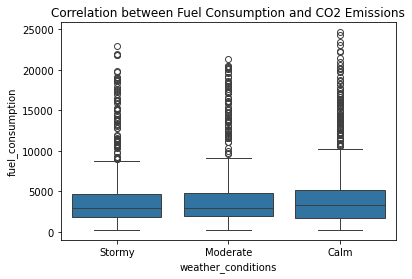

In [9]:
sns.boxplot(
    data=df,
    x='weather_conditions',
    y='fuel_consumption'
)
plt.title('Correlation between Fuel Consumption and CO2 Emissions')

__CO2 Emissions per Distance Unit by Fuel Type__

In [11]:
# CO2 per mile by fuel type
df['CO2_per_mile'] = df['CO2_emissions'] / df['distance']
fuel_comparison = df.groupby('fuel_type')['CO2_per_mile'].mean()
fuel_comparison

fuel_type
Diesel    72.774680
HFO       88.954892
Name: CO2_per_mile, dtype: float64

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df, 
    x='fuel_type', 
    y='CO2_per_mile', 
    errorbar=None,  
    palette='muted'
)


plt.title('CO2 Emissions per Distance Unit: Diesel vs HFO')
plt.xlabel('Fuel Type')
plt.ylabel('Average CO2 per Mile')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

__Monthly Carbon Footprint (CO2 Emissions Trends)__

Text(0, 0.5, 'CO2 Emissions')

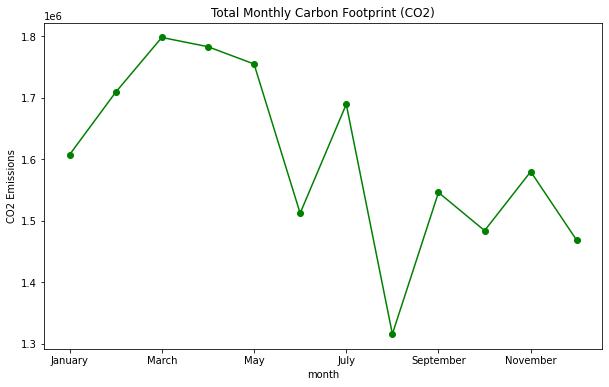

In [14]:
plt.figure(figsize=(10,6))
monthly_co2 = df.groupby('month')['CO2_emissions'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'])
monthly_co2.plot(kind='line', marker='o', color='green')
plt.title('Total Monthly Carbon Footprint (CO2)')
plt.ylabel('CO2 Emissions')

__Engine Efficiency vs. Fuel Consumption Analysis__

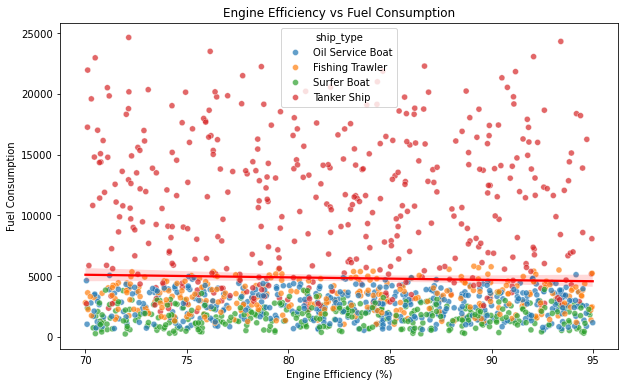

In [8]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='engine_efficiency', y='fuel_consumption', hue='ship_type', alpha=0.7)
sns.regplot(data=df, x='engine_efficiency', y='fuel_consumption', scatter=False, color='red')
plt.title('Engine Efficiency vs Fuel Consumption')
plt.xlabel('Engine Efficiency (%)')
plt.ylabel('Fuel Consumption')
plt.show()

__Correlation Analysis of Numeric Features__

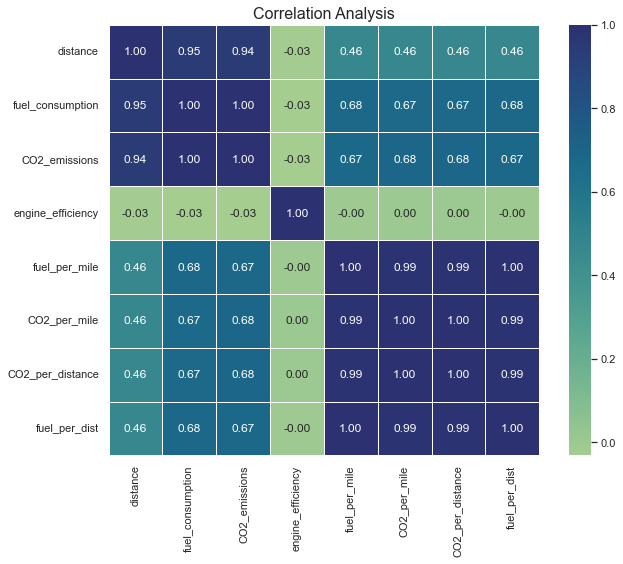

In [55]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='crest',
    fmt='.2f',
    linewidths=0.5,
    square=True)

plt.title('Correlation Analysis', fontsize=16)

plt.tight_layout()
plt.show()